# Rolex Watch Price Analysis - Part 5: Regression Modeling
## Final Project - Data Analytics

## Libraries and settings

In [55]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## Import Cleaned Data

In [56]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2373, 19)


,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
1,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
2,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
3,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
4,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0


## 1. Data Preparation for Modeling

### 1.1 Encode Categorical Variables

In [57]:
df_model = df.copy()

le_condition = LabelEncoder()
le_material = LabelEncoder()
le_movement = LabelEncoder()

df_model['condition_encoded'] = le_condition.fit_transform(df_model['condition_category'])
df_model['material_encoded'] = le_material.fit_transform(df_model['material_category'])
df_model['movement_encoded'] = le_movement.fit_transform(df_model['movement_type'])

print("Encoding mappings:")
print("\nCondition:")
for i, label in enumerate(le_condition.classes_):
    print(f"  {i}: {label}")
print("\nMaterial:")
for i, label in enumerate(le_material.classes_):
    print(f"  {i}: {label}")
print("\nMovement:")
for i, label in enumerate(le_movement.classes_):
    print(f"  {i}: {label}")

Encoding mappings:

Condition:
  0: Fair
  1: Good
  2: New
  3: Unknown
  4: Very Good

Material:
  0: Gold/Steel
  1: Other
  2: Platinum
  3: Rose Gold
  4: Steel
  5: White Gold
  6: Yellow Gold

Movement:
  0: Automatic
  1: Manual
  2: Quartz
  3: Unknown


### 1.2 Select Features for Modeling

In [58]:
# Check for zero variance features before modeling
print("Checking feature variance:")
print(f"  has_box unique values: {df['has_box'].unique()}")
print(f"  has_papers unique values: {df['has_papers'].unique()}")
print(f"  has_complete_set unique values: {df['has_complete_set'].unique()}")
print("\nNote: Features with zero variance (all same value) will cause multicollinearity issues.")
print("Excluding has_box, has_papers, has_complete_set from the model.\n")

df_model = df_model.dropna(subset=['price', 'year', 'age'])

# Use features with actual variance
feature_cols = ['year', 'age', 'condition_encoded', 'material_encoded', 
                'movement_encoded', 'is_professional']

X = df_model[feature_cols]
y = df_model['price']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures used for modeling:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")
    
print(f"\nFeature variance check:")
for col in feature_cols:
    print(f"  {col}: std = {X[col].std():.4f}")

Checking feature variance:
  has_box unique values: [1]
  has_papers unique values: [1]
  has_complete_set unique values: [1]

Note: Features with zero variance (all same value) will cause multicollinearity issues.
Excluding has_box, has_papers, has_complete_set from the model.

Feature matrix shape: (1174, 6)
Target variable shape: (1174,)

Features used for modeling:
  1. year
  2. age
  3. condition_encoded
  4. material_encoded
  5. movement_encoded
  6. is_professional

Feature variance check:
  year: std = 15.5358
  age: std = 15.5358
  condition_encoded: std = 1.1615
  material_encoded: std = 1.7811
  movement_encoded: std = 0.9644
  is_professional: std = 0.4874


### 1.3 Train-Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set price statistics:")
print(f"  Mean: {y_train.mean():,.2f} CHF")
print(f"  Median: {y_train.median():,.2f} CHF")
print(f"  Std: {y_train.std():,.2f} CHF")

Training set size: 939 samples (80.0%)
Test set size: 235 samples (20.0%)

Training set price statistics:
  Mean: 13,626.50 CHF
  Median: 10,576.00 CHF
  Std: 13,185.75 CHF


## 2. Multiple Linear Regression (Statsmodels)

### 2.1 Fit the Model

In [60]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_const)
ols_results = ols_model.fit()

print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     17.48
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           1.42e-16
Time:                        13:45:50   Log-Likelihood:                -10198.
No. Observations:                 939   AIC:                         2.041e+04
Df Residuals:                     933   BIC:                         2.044e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1022      0.01

### 2.2 Model Interpretation

In [61]:
print("Multiple Linear Regression - Key Results")
print("="*70)
print(f"\nR-squared: {ols_results.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_results.rsquared_adj:.4f}")
print(f"F-statistic: {ols_results.fvalue:.2f}")
print(f"Prob (F-statistic): {ols_results.f_pvalue:.6f}")

print(f"\nCoefficients and Significance:")
# Create feature names including the constant
feature_names = ['const'] + feature_cols
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ols_results.params.values,
    'P-value': ols_results.pvalues.values,
    'Significant': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
                    for p in ols_results.pvalues.values]
})
print(coef_df.to_string(index=False))

print(f"\nInterpretation:")
print(f"  - R-squared of {ols_results.rsquared:.4f} means the model explains {ols_results.rsquared*100:.2f}% of price variance")
print(f"  - Features with p < 0.05 have statistically significant effects on price")
print(f"  - Positive coefficients indicate price increases with the feature")
print(f"  - Negative coefficients indicate price decreases with the feature")

Multiple Linear Regression - Key Results

R-squared: 0.0857
Adjusted R-squared: 0.0808
F-statistic: 17.48
Prob (F-statistic): 0.000000

Coefficients and Significance:
          Feature  Coefficient      P-value Significant
            const    -0.102172 5.751152e-15         ***
             year     5.974040 3.994617e-11         ***
              age  -212.769981 1.573650e-15         ***
condition_encoded   259.493393 4.957004e-01            
 material_encoded   627.669479 6.479347e-03          **
 movement_encoded   414.108737 3.344238e-01            
  is_professional  2701.416478 2.961755e-03          **

Interpretation:
  - R-squared of 0.0857 means the model explains 8.57% of price variance
  - Features with p < 0.05 have statistically significant effects on price
  - Positive coefficients indicate price increases with the feature
  - Negative coefficients indicate price decreases with the feature


### 2.3 Model Predictions and Evaluation

In [62]:
y_pred_train_ols = ols_results.predict(X_train_const)
y_pred_test_ols = ols_results.predict(X_test_const)

r2_train_ols = r2_score(y_train, y_pred_train_ols)
r2_test_ols = r2_score(y_test, y_pred_test_ols)
rmse_train_ols = np.sqrt(mean_squared_error(y_train, y_pred_train_ols))
rmse_test_ols = np.sqrt(mean_squared_error(y_test, y_pred_test_ols))
mae_train_ols = mean_absolute_error(y_train, y_pred_train_ols)
mae_test_ols = mean_absolute_error(y_test, y_pred_test_ols)

print("Multiple Linear Regression - Performance Metrics")
print("="*70)
print(f"\nTraining Set:")
print(f"  R-squared: {r2_train_ols:.4f}")
print(f"  RMSE: {rmse_train_ols:,.2f} CHF")
print(f"  MAE: {mae_train_ols:,.2f} CHF")
print(f"\nTest Set:")
print(f"  R-squared: {r2_test_ols:.4f}")
print(f"  RMSE: {rmse_test_ols:,.2f} CHF")
print(f"  MAE: {mae_test_ols:,.2f} CHF")

print(f"\nSample Predictions (first 10 test samples):")
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_test_ols[:10],
    'Difference': y_test.values[:10] - y_pred_test_ols[:10]
})
print(comparison_df.round(2).to_string())

Multiple Linear Regression - Performance Metrics

Training Set:
  R-squared: 0.0857
  RMSE: 12,601.69 CHF
  MAE: 6,962.47 CHF

Test Set:
  R-squared: -0.0039
  RMSE: 11,141.75 CHF
  MAE: 6,780.96 CHF

Sample Predictions (first 10 test samples):
       Actual  Predicted  Difference
822   78402.0   15180.31    63221.69
941    7972.0   13625.55    -5653.55
1353   7693.0   16687.97    -8994.97
327    9373.0   15202.52    -5829.52
1782  18892.0   17822.44     1069.56
1336   4996.0    8640.20    -3644.20
2210  58025.0   15145.95    42879.05
1803  14492.0   17822.44    -3330.44
86     8877.0   14327.54    -5450.54
2276   5732.0   12872.82    -7140.82


### 2.4 Residuals Analysis

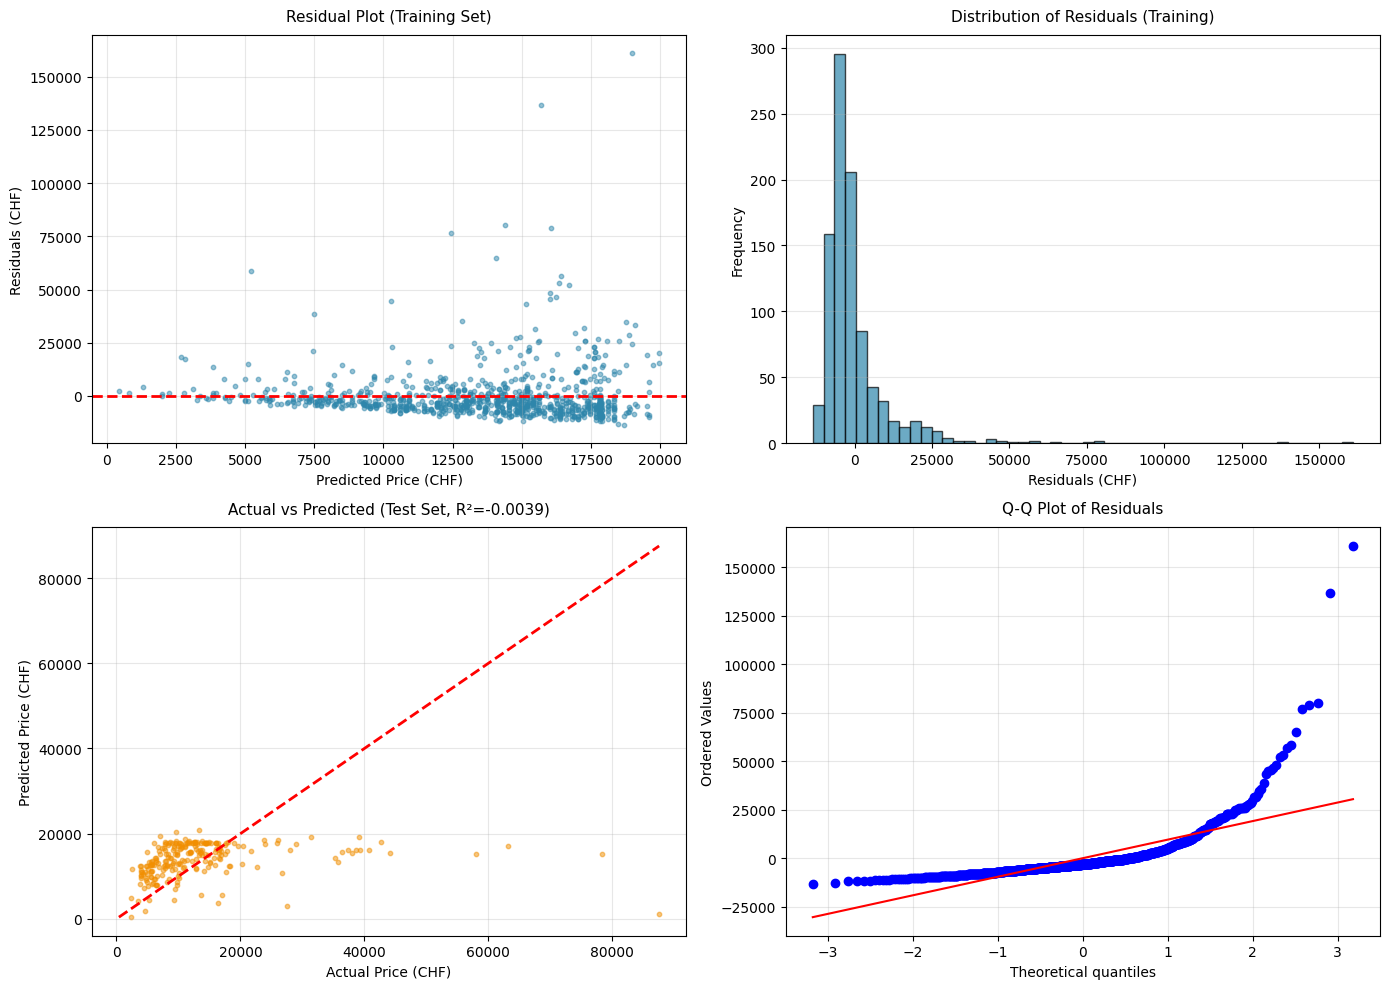

Residuals Analysis:
  Mean of residuals: -0.00 CHF (should be close to 0)
  Std of residuals: 12,608.40 CHF


In [63]:
residuals_train = y_train - y_pred_train_ols
residuals_test = y_test - y_pred_test_ols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_pred_train_ols, residuals_train, s=10, alpha=0.5, color='#2E86AB')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price (CHF)', fontsize=10)
axes[0, 0].set_ylabel('Residuals (CHF)', fontsize=10)
axes[0, 0].set_title('Residual Plot (Training Set)', fontsize=11, pad=10)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(residuals_train, bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals (CHF)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Distribution of Residuals (Training)', fontsize=11, pad=10)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].scatter(y_test, y_pred_test_ols, s=10, alpha=0.5, color='#F18F01')
min_val = min(y_test.min(), y_pred_test_ols.min())
max_val = max(y_test.max(), y_pred_test_ols.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1, 0].set_xlabel('Actual Price (CHF)', fontsize=10)
axes[1, 0].set_ylabel('Predicted Price (CHF)', fontsize=10)
axes[1, 0].set_title(f'Actual vs Predicted (Test Set, R²={r2_test_ols:.4f})', fontsize=11, pad=10)
axes[1, 0].grid(alpha=0.3)

stats.probplot(residuals_train, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontsize=11, pad=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals Analysis:")
print(f"  Mean of residuals: {residuals_train.mean():.2f} CHF (should be close to 0)")
print(f"  Std of residuals: {residuals_train.std():,.2f} CHF")

### Interpretation

Residual analysis helps assess model assumptions:
- Residuals should be randomly scattered around zero (no patterns)
- Histogram should approximate a normal distribution
- Q-Q plot should show points close to the diagonal line
- Actual vs Predicted plot shows how well predictions match reality

## 3. Random Forest Regression

### 3.1 Fit the Random Forest Model

In [64]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Model Parameters:")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Max depth: {rf_model.max_depth}")
print(f"  Number of features: {rf_model.n_features_in_}")
print(f"\nModel training completed successfully.")

Random Forest Model Parameters:
  Number of trees: 200
  Max depth: 15
  Number of features: 6

Model training completed successfully.


### 3.2 Model Predictions and Evaluation

In [65]:
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)

print("Random Forest Regression - Performance Metrics")
print("="*70)
print(f"\nTraining Set:")
print(f"  R-squared: {r2_train_rf:.4f}")
print(f"  RMSE: {rmse_train_rf:,.2f} CHF")
print(f"  MAE: {mae_train_rf:,.2f} CHF")
print(f"\nTest Set:")
print(f"  R-squared: {r2_test_rf:.4f}")
print(f"  RMSE: {rmse_test_rf:,.2f} CHF")
print(f"  MAE: {mae_test_rf:,.2f} CHF")

print(f"\nSample Predictions (first 10 test samples):")
comparison_df_rf = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_test_rf[:10],
    'Difference': y_test.values[:10] - y_pred_test_rf[:10]
})
print(comparison_df_rf.round(2).to_string())

Random Forest Regression - Performance Metrics

Training Set:
  R-squared: 0.7945
  RMSE: 5,973.96 CHF
  MAE: 3,050.53 CHF

Test Set:
  R-squared: -0.1860
  RMSE: 12,110.25 CHF
  MAE: 5,561.94 CHF

Sample Predictions (first 10 test samples):
    Actual  Predicted  Difference
0  78402.0   18297.80    60104.20
1   7972.0    5150.97     2821.03
2   7693.0   12550.49    -4857.49
3   9373.0   14484.51    -5111.51
4  18892.0   13429.30     5462.70
5   4996.0    5258.25     -262.25
6  58025.0   37037.96    20987.04
7  14492.0   13429.30     1062.70
8   8877.0    9529.82     -652.82
9   5732.0    6218.30     -486.30


### 3.3 Feature Importance

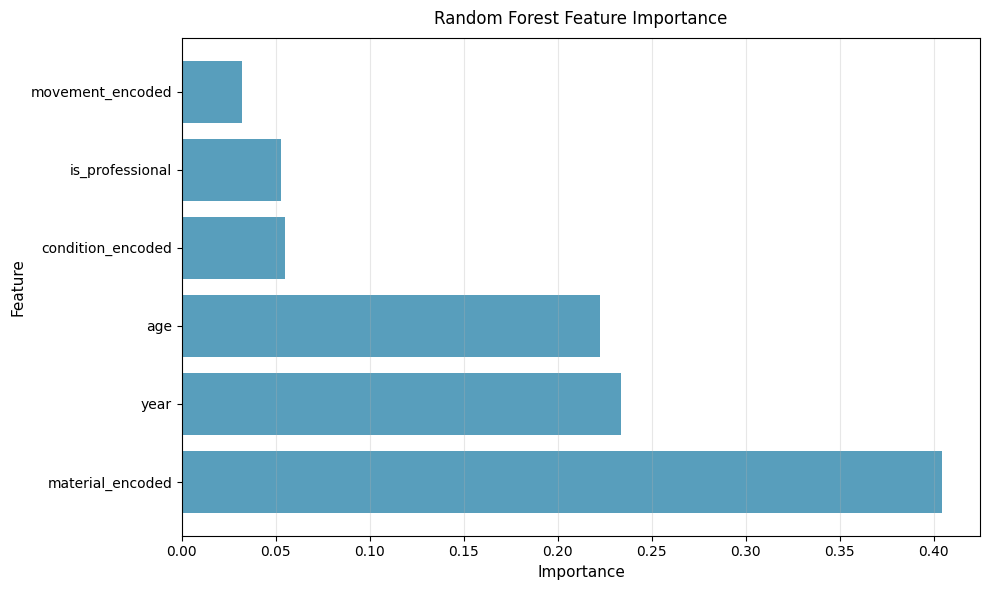

Feature Importance Ranking:
  material_encoded         : 0.4045
  year                     : 0.2339
  age                      : 0.2227
  condition_encoded        : 0.0547
  is_professional          : 0.0525
  movement_encoded         : 0.0317


In [66]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['Importance'].values, 
         color='#2E86AB', alpha=0.8)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'].values)
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Random Forest Feature Importance', fontsize=12, pad=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for i, row in feature_importance.iterrows():
    print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")

### Interpretation

Feature importance in Random Forest indicates which variables contribute most to prediction accuracy. Higher values mean the feature is more important for making accurate predictions.

### 3.4 Random Forest Residuals Analysis

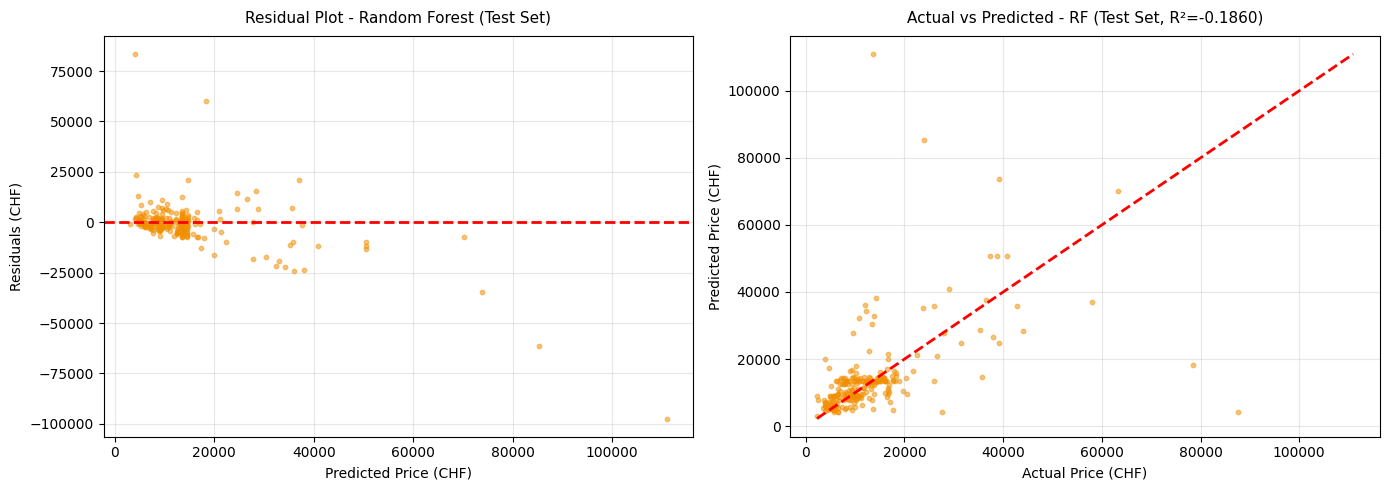

Random Forest Residuals Statistics (Test Set):
  Mean of residuals: -992.22 CHF
  Std of residuals: 12,095.29 CHF
  Min residual: -97,334.03 CHF
  Max residual: 83,395.25 CHF


In [67]:
residuals_train_rf = y_train - y_pred_train_rf
residuals_test_rf = y_test - y_pred_test_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test_rf, residuals_test_rf, s=10, alpha=0.5, color='#F18F01')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price (CHF)', fontsize=10)
axes[0].set_ylabel('Residuals (CHF)', fontsize=10)
axes[0].set_title('Residual Plot - Random Forest (Test Set)', fontsize=11, pad=10)
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred_test_rf, s=10, alpha=0.5, color='#F18F01')
min_val = min(y_test.min(), y_pred_test_rf.min())
max_val = max(y_test.max(), y_pred_test_rf.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Price (CHF)', fontsize=10)
axes[1].set_ylabel('Predicted Price (CHF)', fontsize=10)
axes[1].set_title(f'Actual vs Predicted - RF (Test Set, R²={r2_test_rf:.4f})', fontsize=11, pad=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Random Forest Residuals Statistics (Test Set):")
print(f"  Mean of residuals: {residuals_test_rf.mean():.2f} CHF")
print(f"  Std of residuals: {residuals_test_rf.std():,.2f} CHF")
print(f"  Min residual: {residuals_test_rf.min():,.2f} CHF")
print(f"  Max residual: {residuals_test_rf.max():,.2f} CHF")

## 4. Model Comparison

Model Performance Comparison
            Model  Dataset  R-squared         RMSE         MAE
Linear Regression Training   0.085654 12601.688424 6962.471118
Linear Regression     Test  -0.003879 11141.747552 6780.958959
    Random Forest Training   0.794516  5973.956736 3050.534017
    Random Forest     Test  -0.185989 12110.246043 5561.944964


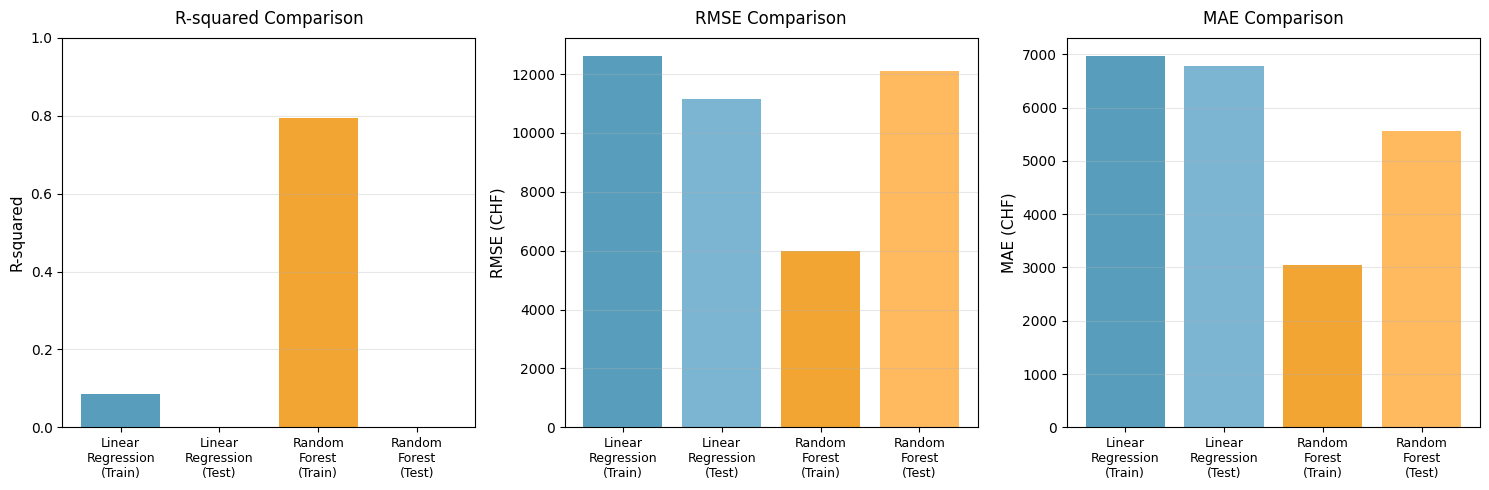


Interpretation:
  - R-squared: Higher is better (closer to 1 means better fit)
  - RMSE & MAE: Lower is better (smaller prediction errors)
  - Linear Regression performs better on test data (R² = -0.0039 vs -0.1860)
  - Linear Regression overfitting gap: 0.0895
  - Random Forest overfitting gap: 0.9805


In [68]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Linear Regression', 'Random Forest', 'Random Forest'],
    'Dataset': ['Training', 'Test', 'Training', 'Test'],
    'R-squared': [r2_train_ols, r2_test_ols, r2_train_rf, r2_test_rf],
    'RMSE': [rmse_train_ols, rmse_test_ols, rmse_train_rf, rmse_test_rf],
    'MAE': [mae_train_ols, mae_test_ols, mae_train_rf, mae_test_rf]
})

print("Model Performance Comparison")
print("="*80)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Linear\nRegression\n(Train)', 'Linear\nRegression\n(Test)', 
          'Random\nForest\n(Train)', 'Random\nForest\n(Test)']
r2_values = [r2_train_ols, r2_test_ols, r2_train_rf, r2_test_rf]
rmse_values = [rmse_train_ols, rmse_test_ols, rmse_train_rf, rmse_test_rf]
mae_values = [mae_train_ols, mae_test_ols, mae_train_rf, mae_test_rf]
colors = ['#2E86AB', '#5BA3C7', '#F18F01', '#FFA938']

axes[0].bar(range(4), r2_values, color=colors, alpha=0.8)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel('R-squared', fontsize=11)
axes[0].set_title('R-squared Comparison', fontsize=12, pad=10)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(4), rmse_values, color=colors, alpha=0.8)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel('RMSE (CHF)', fontsize=11)
axes[1].set_title('RMSE Comparison', fontsize=12, pad=10)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(4), mae_values, color=colors, alpha=0.8)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylabel('MAE (CHF)', fontsize=11)
axes[2].set_title('MAE Comparison', fontsize=12, pad=10)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  - R-squared: Higher is better (closer to 1 means better fit)")
print(f"  - RMSE & MAE: Lower is better (smaller prediction errors)")
if r2_test_rf > r2_test_ols:
    print(f"  - Random Forest performs better on test data (R² = {r2_test_rf:.4f} vs {r2_test_ols:.4f})")
else:
    print(f"  - Linear Regression performs better on test data (R² = {r2_test_ols:.4f} vs {r2_test_rf:.4f})")
    
overfitting_ols = r2_train_ols - r2_test_ols
overfitting_rf = r2_train_rf - r2_test_rf
print(f"  - Linear Regression overfitting gap: {overfitting_ols:.4f}")
print(f"  - Random Forest overfitting gap: {overfitting_rf:.4f}")

## 5. Predictions Comparison on Sample Data

Sample Predictions Comparison (random 20 test samples):
     Actual  Linear_Reg  Random_Forest  Error_LR  Error_RF
0    6614.0     7955.96        4208.62  -1341.96   2405.38
1   78402.0    15180.31       18297.80  63221.69  60104.20
2    5011.0    12313.09        8405.75  -7302.09  -3394.75
3   16106.0    17822.44       13429.30  -1716.44   2676.70
4    3988.0    11046.38        6136.36  -7058.38  -2148.36
5    7742.0    12358.85        7747.02  -4616.85     -5.02
6   17640.0    17822.44       13429.30   -182.44   4210.70
7    4033.0    11483.87        5813.71  -7450.87  -1780.71
8   14128.0    11284.49       13293.47   2843.51    834.53
9   16615.0    16274.85       21440.92    340.15  -4825.92
10   8945.0    12577.59        9108.01  -3632.59   -163.01
11   7896.0    13643.31       10306.00  -5747.31  -2410.00
12  10051.0    17822.44       13429.30  -7771.44  -3378.30
13   8877.0    14327.54        9529.82  -5450.54   -652.82
14   4948.0    15716.49        9075.41 -10768.49  -4127.41


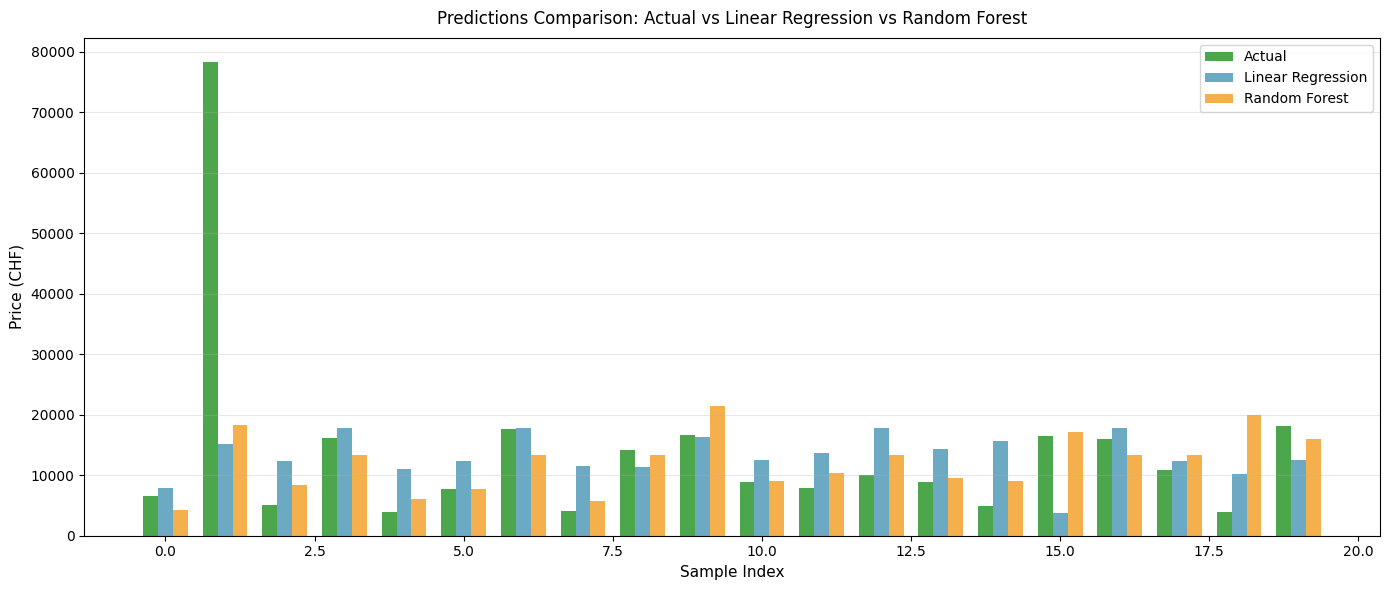

In [69]:
sample_size = 20
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

# Use .iloc for positional indexing to avoid KeyError with pandas indices
comparison_sample = pd.DataFrame({
    'Actual': y_test.iloc[sample_indices].values,
    'Linear_Reg': y_pred_test_ols.iloc[sample_indices].values,
    'Random_Forest': y_pred_test_rf[sample_indices],
    'Error_LR': y_test.iloc[sample_indices].values - y_pred_test_ols.iloc[sample_indices].values,
    'Error_RF': y_test.iloc[sample_indices].values - y_pred_test_rf[sample_indices]
})

print(f"Sample Predictions Comparison (random {sample_size} test samples):")
print("="*80)
print(comparison_sample.round(2).to_string())

x_pos = np.arange(sample_size)
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x_pos - width, comparison_sample['Actual'], width, label='Actual', color='green', alpha=0.7)
plt.bar(x_pos, comparison_sample['Linear_Reg'], width, label='Linear Regression', color='#2E86AB', alpha=0.7)
plt.bar(x_pos + width, comparison_sample['Random_Forest'], width, label='Random Forest', color='#F18F01', alpha=0.7)
plt.xlabel('Sample Index', fontsize=11)
plt.ylabel('Price (CHF)', fontsize=11)
plt.title('Predictions Comparison: Actual vs Linear Regression vs Random Forest', fontsize=12, pad=10)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [70]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-29 13:45:51
Python Version: 3.11.13
-----------------------------------
